# NBD-Bass 統合モデル: 規制ダミー化版（$p_1(t)$ 外生化・イベント訂正版）

## 変更点

前版（2004, 2018）を**遊技業界データブック 2025** の記述に基づき訂正:

- **2004 を 2006 に訂正**: 2004 は台数ピーク年（結果）であり規制年ではない。正しい規制施行は **2006（平成18、旧規則機経過措置満了 = 5号機ショック）**
- **2011 を追加**: **東日本大震災**（マクロショック）
- **2018 は維持**: 遊技機規則改正（射幸性抑制）

$$p_1(t) = p_{1,\text{base}} + \beta_{2006} \cdot I(t \geq 2006) + \beta_{2011} \cdot I(t \geq 2011) + \beta_{2018} \cdot I(t \geq 2018)$$

| 係数 | 意味 | 予想符号 |
|---|---|---|
| $p_{1,\text{base}}$ | 1994-2005 の平常時加入率 | +（定常） |
| $\beta_{2006}$ | 5号機ショック | − |
| $\beta_{2011}$ | 東日本大震災（供給・需要両面の打撃） | − |
| $\beta_{2018}$ | 新規則施行（射幸性抑制） | − |

規制・災害は**因果的に外生**（プレイヤー数で発生時期は決まらない）。

## その他の設定

- $p_2(t)$: ガウス摂動のまま（スマホ期の離脱は連続的）
- NBD 部分: 時変 $r(t), \alpha(t)$ のまま
- 観測: 参加人口（正規）+ 頻度分布（Multinomial, n=1500）

## 全パラメータ

$$p_{1,\text{base}}, \beta_{2006}, \beta_{2011}, \beta_{2018},\ p_{2,\text{base}}, A_2, c_2, w_2,\ q_1, \alpha, M, \sigma,\ r_0, r_1, a_0, a_1$$

合計 **16 パラメータ**。

In [9]:
ENV["GKS_ENCODING"] = "utf8"
using DifferentialEquations, Turing, Distributions
using DataFrames, CSV, Plots, StatsPlots, Statistics, Printf, Random, SpecialFunctions
gr(fontfamily="PlemolJP-Text")
Random.seed!(20260415);

In [10]:
# データ読み込み（統合版と同じ）
df_active = CSV.read(raw"C:\Users\kimse\OneDrive\Jupyter_notebook\Pachinko\p-datasets2.csv",
                     DataFrame; missingstring="")
df_active = dropmissing(df_active[:, [:年, :パチンコ参加人口]])
df_active.A_man = df_active.パチンコ参加人口 ./ 10
t_bass = Float64.(df_active.年)
A_bass = Float64.(df_active.A_man)

df_freq = CSV.read(raw"C:\Users\kimse\OneDrive\Jupyter_notebook\data\パチンコ頻度データ.csv",
                   DataFrame; stripwhitespace=true)
rename!(df_freq, names(df_freq) .=> [:年, :heavy, :middle, :lmiddle,
                                      :light_old, :rare_old, :light_new, :rare_new])
df_freq.light = coalesce.(df_freq.light_new, df_freq.light_old)
df_freq.rare  = coalesce.(df_freq.rare_new,  df_freq.rare_old)
df_freq.is_post2013 = df_freq.年 .>= 2013
const N_SURVEY = 1500
df_freq.n_heavy   = round.(Int, df_freq.heavy   .* N_SURVEY)
df_freq.n_middle  = round.(Int, df_freq.middle  .* N_SURVEY)
df_freq.n_lmiddle = round.(Int, df_freq.lmiddle .* N_SURVEY)
df_freq.n_light   = round.(Int, df_freq.light   .* N_SURVEY)
df_freq.n_rare    = round.(Int, df_freq.rare    .* N_SURVEY)
for r in eachrow(df_freq)
    s = r.n_heavy + r.n_middle + r.n_lmiddle + r.n_light + r.n_rare
    r.n_heavy += (N_SURVEY - s)
end
println("Bass data: N=$(length(t_bass)), 頻度 data: N=$(nrow(df_freq))")

Bass data: N=26, 頻度 data: N=10


In [11]:
# NBD ヘルパー
function log_nbd_pmf(k::Int, r, α)
    loggamma(r + k) - loggamma(r) - loggamma(k + 1.0) +
        r * log(α / (α + 1)) + k * log(1 / (α + 1))
end

function nbd_cdf(lo::Int, r, α)
    s = zero(r * α)
    for k in 0:(lo - 1)
        s += exp(log_nbd_pmf(k, r, α))
    end
    return s
end

function bin_probs(r, α, bins)
    T = typeof(r * α)
    ps = Vector{T}(undef, length(bins))
    for (i, (lo, hi)) in enumerate(bins)
        if hi > 5000
            ps[i] = 1.0 - nbd_cdf(lo, r, α)
        else
            ps[i] = nbd_cdf(hi, r, α) - nbd_cdf(lo, r, α)
        end
    end
    p0 = exp(r * log(α / (α + 1)))
    p_active = 1.0 - p0
    return ps, p_active
end

const BINS_POST = [(104, 10_000), (48, 104), (12, 48), (4, 12), (1, 4)]
const BINS_PRE  = [(104, 10_000), (48, 104), (12, 48), (5, 12), (2, 5)]

5-element Vector{Tuple{Int64, Int64}}:
 (104, 10000)
 (48, 104)
 (12, 48)
 (5, 12)
 (2, 5)

In [12]:
# Bass 3状態 ODE: p1(t) は 2006, 2011, 2018 のステップ関数
function p1_step(t, p1_b, β2006, β2011, β2018)
    p = p1_b
    if t >= 2006.0; p += β2006; end
    if t >= 2011.0; p += β2011; end
    if t >= 2018.0; p += β2018; end
    return p
end

function bass_reg!(du, u, params, t)
    s, a, x = u
    p1_b, β2006, β2011, β2018, p2_b, A2, c2, w2, q1, α = params
    s = clamp(s, 0.0, 1.0); a = clamp(a, 0.0, 1.0); x = clamp(x, 0.0, 1.0)
    p1_t = p1_step(t, p1_b, β2006, β2011, β2018)
    p2_t = p2_b + A2 * exp(-0.5 * ((t - c2)/w2)^2)
    adoption = p1_t + q1 * a
    f_in      = adoption * s
    f_readopt = α * adoption * x
    f_out     = p2_t * a
    du[1] = -f_in
    du[2] = f_in + f_readopt - f_out
    du[3] = f_out - f_readopt
end

function solve_reg_a(p1_b, β2006, β2011, β2018, p2_b, A2, c2, w2, q1, α, a0, t_eval)
    u0 = [1.0 - a0, a0, 0.0]
    tspan = (t_eval[1] - 1.0, t_eval[end] + 1.0)
    params = (p1_b, β2006, β2011, β2018, p2_b, A2, c2, w2, q1, α)
    prob = ODEProblem(bass_reg!, u0, tspan, params)
    sol = solve(prob, Tsit5(); saveat=t_eval, tstops=[2006.0, 2011.0, 2018.0],
                abstol=1e-6, reltol=1e-6, maxiters=50_000)
    T = promote_type(typeof(p1_b), typeof(β2006), typeof(β2011), typeof(β2018),
                     typeof(p2_b), typeof(A2), typeof(c2), typeof(w2),
                     typeof(q1), typeof(α))
    a_pred = zeros(T, length(t_eval))
    for i in eachindex(t_eval)
        a_pred[i] = i <= length(sol.t) ? sol.u[i][2] : zero(T)
    end
    return a_pred
end;

In [13]:
# Turing 統合モデル
@model function nbd_bass_regulation(t_bass, A_bass, a0_init,
                                     t_freq, freq_counts, freq_is_post)
    # Bass パラメータ
    p1_base ~ Uniform(0.0, 0.3)
    β2006   ~ Uniform(-0.2, 0.2)
    β2011   ~ Uniform(-0.2, 0.2)
    β2018   ~ Uniform(-0.2, 0.2)
    p2_base ~ Uniform(0.0, 0.3)
    A2      ~ Uniform(0.0, 0.5)
    c2      ~ Uniform(2005.0, 2019.0)
    w2      ~ Uniform(0.5, 5.0)
    q1      ~ Uniform(0.0, 2.0)
    α       ~ Uniform(0.0, 1.0)
    M       ~ Uniform(1500.0, 5000.0)
    σ       ~ Uniform(20.0, 500.0)
    # NBD 時変
    r0 ~ Uniform(log(0.05), log(5.0))
    r1 ~ Uniform(-0.2, 0.2)
    a0_nbd ~ Uniform(log(0.001), log(1.0))
    a1_nbd ~ Uniform(-0.3, 0.3)

    a_pred = solve_reg_a(p1_base, β2006, β2011, β2018, p2_base, A2, c2, w2,
                          q1, α, a0_init, t_bass)
    for i in eachindex(t_bass)
        t = t_bass[i]
        r_t = exp(r0 + r1 * (t - 2013.0))
        α_t = exp(a0_nbd + a1_nbd * (t - 2013.0))
        p0 = exp(r_t * log(α_t / (α_t + 1)))
        p_active = 1.0 - p0
        pred = M * a_pred[i] * p_active
        A_bass[i] ~ Normal(pred, σ)
    end
    for j in eachindex(t_freq)
        t = t_freq[j]
        r_t = exp(r0 + r1 * (t - 2013.0))
        α_t = exp(a0_nbd + a1_nbd * (t - 2013.0))
        bins = freq_is_post[j] ? BINS_POST : BINS_PRE
        ps, p_active = bin_probs(r_t, α_t, bins)
        p_cond = ps ./ p_active
        p_cond = max.(p_cond, 1e-10)
        p_cond = p_cond ./ sum(p_cond)
        freq_counts[j, :] ~ Multinomial(N_SURVEY, p_cond)
    end
end;

In [14]:
# MCMC
t_freq = Float64.(df_freq.年)
freq_counts = Matrix{Int}(undef, nrow(df_freq), 5)
for (i, r) in enumerate(eachrow(df_freq))
    freq_counts[i, :] = [r.n_heavy, r.n_middle, r.n_lmiddle, r.n_light, r.n_rare]
end
freq_is_post = Bool.(df_freq.is_post2013)
a0_init = A_bass[1] / 2500.0

model = nbd_bass_regulation(t_bass, A_bass, a0_init, t_freq, freq_counts, freq_is_post)

init_vals = (; p1_base=0.05, β2006=-0.02, β2011=-0.02, β2018=-0.02,
              p2_base=0.05, A2=0.15, c2=2015.0, w2=2.0,
              q1=0.5, α=0.3, M=2500.0, σ=150.0,
              r0=log(0.5), r1=0.0, a0_nbd=log(0.01), a1_nbd=0.0)
n_chains = 4
@time chain = sample(model, NUTS(0.9; max_depth=10), MCMCThreads(), 1000, n_chains;
                     initial_params=fill(init_vals, n_chains))

[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
[ Info: Using a NamedTuple for `initial_params` will be deprecated in a future release. Please use `InitFromParams(namedtuple)` instead.
┌ Warning: Only a single thread available: MCMC chains are not sampled in parallel
└ @ AbstractMCMC C:\Users\kimse\.julia\packages\AbstractMCMC\oqm6Y\src\sample.jl:544
┌ Info: Found initial step size
└   ϵ = 0.0125
Sampling (1 thread):  25%|████████                      |  ETA: 0:17:08┌ Info: Found initial step size
└   ϵ = 0.0125
Sampling (1 thread):  50%|████████████████              |  ETA: 0:13:18┌ Info: Found initial step size
└   ϵ = 0.0125
S

1590.089227 seconds (1.31 G allocations: 150.163 GiB, 1.35% gc time, 1.02% compilation time: <1% of which was recompilation)


Chains MCMC chain (1000×30×4 Array{Float64, 3}):

Iterations        = 501:1:1500
Number of chains  = 4
Samples per chain = 1000
Wall duration     = 1582.52 seconds
Compute duration  = 1580.14 seconds
parameters        = p1_base, β2006, β2011, β2018, p2_base, A2, c2, w2, q1, α, M, σ, r0, r1, a0_nbd, a1_nbd
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Use `describe(chains)` for summary statistics and quantiles.


In [15]:
ENV["COLUMNS"] = "200"
display(summarize(chain))

params_show = [:p1_base, :β2006, :β2011, :β2018, :p2_base, :A2, :c2, :w2,
               :q1, :α, :M, :σ, :r0, :r1, :a0_nbd, :a1_nbd]
println("\n=== 事後分布 Quantile ===")
@printf("%-10s %12s %12s %12s %10s\n", "param", "2.5%", "50%", "97.5%", "CI/med")
for p in params_show
    v = vec(Array(chain[p]))
    q = quantile(v, [0.025, 0.5, 0.975])
    r = (q[3] - q[1]) / abs(q[2])
    mark = r < 1.0 ? "○" : r < 2.0 ? "△" : "✗"
    @printf("%-10s %12.4g %12.4g %12.4g %8.2f %s\n", string(p), q[1], q[2], q[3], r, mark)
end

# β の 95%CI がゼロを跨ぐか（有意性判定）
println("\n=== 規制・震災効果の有意性 ===")
for p in [:β2006, :β2011, :β2018]
    v = vec(Array(chain[p]))
    q = quantile(v, [0.025, 0.5, 0.975])
    sig = (q[1] > 0 || q[3] < 0) ? "✓ 有意" : "✗ ゼロ含む"
    @printf("%-8s: [%8.4f, %8.4f]  %s\n", string(p), q[1], q[3], sig)
end



  parameters        mean        std      mcse    ess_bulk    ess_tail      rhat   ess_per_sec 
      Symbol     Float64    Float64   Float64     Float64     Float64   Float64       Float64 

     p1_base      0.1552     0.0850    0.0015   3042.9263   2021.7232    1.0009        1.9257
       β2006     -0.0021     0.1068    0.0022   2148.6040   1943.9010    1.0012        1.3598
       β2011     -0.0371     0.1045    0.0021   2530.8104   1810.4382    1.0012        1.6016
       β2018     -0.0063     0.1137    0.0018   3645.1055   2381.7817    1.0026        2.3068
     p2_base      0.1530     0.0508    0.0014   1469.0889   1138.4690    1.0030        0.9297
          A2      0.1711     0.1102    0.0029   1303.0789   1344.5891    1.0058        0.8247
          c2   2013.2594     2.4394    0.0702   1248.2799   1015.6111    1.0022        0.7900
          w2      2.8989     1.4237    0.0359   1586.4683   2495.6734    1.0010        1.0040
          q1      0.8723     0.5552    0.0114   2258.09


=== 事後分布 Quantile ===
param              2.5%          50%        97.5%     CI/med
p1_base        0.008896       0.1588       0.2917     1.78 △
β2006            -0.185    -0.004295       0.1851    86.19 ✗
β2011           -0.1928     -0.05054       0.1757     7.29 ✗
β2018           -0.1891    -0.008308       0.1892    45.53 ✗
p2_base         0.07347       0.1452        0.271     1.36 △
A2              0.01317       0.1506       0.4402     2.84 ✗
c2                 2008         2013         2018     0.01 ○
w2               0.5602        3.127        4.932     1.40 △
q1              0.04432       0.8022        1.911     2.33 ✗
α               0.05064       0.1924       0.6383     3.05 ✗
M                  3191         3794         4626     0.38 ○
σ                 121.4        162.2        234.1     0.69 ○
r0               -1.055      -0.9978       -0.941     0.11 ○
r1            -0.005577     0.007656      0.02173     3.57 ✗
a0_nbd           -5.237       -5.174       -5.114     0.02 ○
a

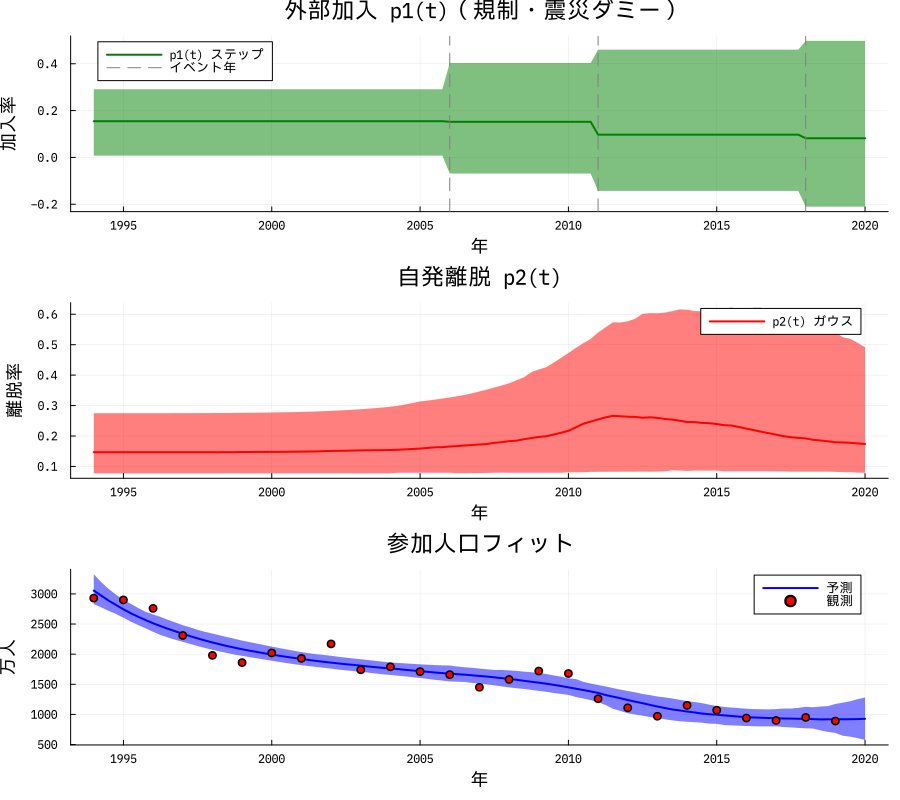

In [16]:
# p1(t), p2(t), A_obs フィット可視化
n_post = 400
idx = rand(1:size(chain,1)*size(chain,3), n_post)
arr = Array(chain); cn = names(chain)
col(p) = findfirst(==(p), cn)

t_grid = collect(1994.0:0.25:2020.0)
p1_samples = zeros(n_post, length(t_grid))
p2_samples = zeros(n_post, length(t_grid))
obs_samples = zeros(n_post, length(t_grid))

for k in 1:n_post
    i = idx[k]
    p1b   = arr[i, col(:p1_base)]
    b2006 = arr[i, col(:β2006)]; b2011 = arr[i, col(:β2011)]; b2018 = arr[i, col(:β2018)]
    p2b   = arr[i, col(:p2_base)]; A2 = arr[i, col(:A2)]
    c2    = arr[i, col(:c2)]; w2 = arr[i, col(:w2)]
    q1    = arr[i, col(:q1)]; αB = arr[i, col(:α)]; M = arr[i, col(:M)]
    r0_k  = arr[i, col(:r0)]; r1_k = arr[i, col(:r1)]
    a0_k  = arr[i, col(:a0_nbd)]; a1_k = arr[i, col(:a1_nbd)]
    a_p = solve_reg_a(p1b, b2006, b2011, b2018, p2b, A2, c2, w2, q1, αB, a0_init, t_grid)
    for (j, t) in enumerate(t_grid)
        p1_samples[k,j] = p1_step(t, p1b, b2006, b2011, b2018)
        p2_samples[k,j] = p2b + A2*exp(-0.5*((t-c2)/w2)^2)
        r_t = exp(r0_k + r1_k * (t - 2013.0))
        α_t = exp(a0_k + a1_k * (t - 2013.0))
        p0 = exp(r_t * log(α_t / (α_t + 1)))
        obs_samples[k,j] = M * a_p[j] * (1.0 - p0)
    end
end
stat(S) = ([quantile(S[:,j], 0.5) for j in 1:size(S,2)],
           [quantile(S[:,j], 0.025) for j in 1:size(S,2)],
           [quantile(S[:,j], 0.975) for j in 1:size(S,2)])
p1_m, p1_lo, p1_hi = stat(p1_samples)
p2_m, p2_lo, p2_hi = stat(p2_samples)
obs_m, obs_lo, obs_hi = stat(obs_samples)

plt1 = plot(t_grid, p1_m, ribbon=(p1_m.-p1_lo, p1_hi.-p1_m),
            lw=2, color=:green, label="p1(t) ステップ",
            xlabel="年", ylabel="加入率", title="外部加入 p1(t)（規制・震災ダミー）")
vline!(plt1, [2006, 2011, 2018], ls=:dash, color=:gray, label="イベント年")
plt2 = plot(t_grid, p2_m, ribbon=(p2_m.-p2_lo, p2_hi.-p2_m),
            lw=2, color=:red, label="p2(t) ガウス",
            xlabel="年", ylabel="離脱率", title="自発離脱 p2(t)")
plt3 = plot(t_grid, obs_m, ribbon=(obs_m.-obs_lo, obs_hi.-obs_m),
            lw=2, color=:blue, label="予測",
            xlabel="年", ylabel="万人", title="参加人口フィット")
scatter!(plt3, t_bass, A_bass, color=:red, ms=4, label="観測")
plot(plt1, plt2, plt3, layout=(3,1), size=(900,800))

## 検証ポイント

1. **$\beta_{2004}$, $\beta_{2018}$ の符号と有意性**: 負に有意なら「規制が加入率を下押し」を検出
2. **$q_1$ の識別性改善**: Gaussian 版との CI/med 比較
3. **$c_2$ の安定性**: 2014 付近でロバストか
4. **$a_1$ (NBD α slope) の変化**: $p_1$ 自由度が減った分、他パラにどう影響するか
5. **フィット品質 $\sigma$**: ステップ関数で滑らかさが失われて悪化していないか